# **INTRODUCTION TO MACHINE LEARNING** 

*In this lesson, we describe the core concepts associated with machine learning. First, we define the boundaries among artificial intelligence, machine learning, and deep learning. Second, we introduce the main features of a machine learning problem in the context of the linear regression model and the time series predictability of stock prices.*

## **1. Machine Learning**


The terms machine (or deep) learning and artificial intelligence are frequently used in the same context or as synonyms. However, all these concepts refer to different things. Thus, we first need to define clearly what we are talking about when we mention all these terms. How do artificial intelligence, machine learning, and deep learning relate to each other? 

### **1.1 Artificial Intelligence, Machine Learning and Deep Learning**

Artificial intelligence (AI) is an academic discipline that studies the ability of any system that perceives its environment and that takes actions that maximize its chance of achieving its goal. AI represents the effort to automate intellectual tasks normally performed by humans.

As such, AI is a general field that encompasses machine learning and
deep learning but that also includes many more approaches that don't involve any learning. For instance, early chess programs only involved hard-coded rules crafted by programmers and are different from machine learning. It turned out to be intractable to figure out explicit rules for solving complex problems, such as image classification or speech recognition. A new approach arose to solve these problems: machine learning.

Machine  learning (ML) is often categorized as a subfield of AI that deals with computer programs that allow computers to learn from data. In classical programming, humans input rules (a program) and data to be processed according to these rules, and the combination of both yields answers. With ML, humans input data as well as the answers expected from the data, while the program dictates the rules.

Fundamentally, ML involves building mathematical models to help understand data. Computers start "learning" when we insert tunable parameters in the programs that can be adapted to observed data. Once these models have been fit to previously seen data, they can be used to predict and understand aspects of newly observed data.

A more precise definition of what requirements a ML program should satisfy is the following:

> *A computer program is said to learn from experience with respect to some task T and some performance measure P, if its performance on T, as measured by P, improves with experience.*

An ML system is trained rather than explicitly programmed. It is presented with many examples relevant to a task, and it finds statistical structure in these examples that eventually allows the system to come up with rules for automating the task.

For instance, the spam filter of your email service is an ML program that learns to detect spam given examples of both spam emails (e.g., flagged by users) and regular emails. The examples that the system uses to learn are called the training set. The task is to flag spam for new emails, the experience is the training data, and the performance measure is, for example, the proportion of correctly classified emails.

Although ML only started to grow in the 1990s, it has quickly become the most popular and most successful subfield of AI, a trend driven by the availability of faster hardware and larger datasets. While ML is tightly related to mathematical statistics, it exhibits comparatively little mathematical theory, and it is engineering-oriented. It is a hands-on discipline in which ideas are most often proven empirically instead of theoretically.

Deep learning (DL) is a specific subfield of ML: A strategy for learning representations from data that puts an emphasis on learning successive layers of increasingly meaningful representations. Modern DL often involves dozens or even hundreds of successive layers of representations, which are all learned automatically from exposure to training data. Meanwhile, other approaches to ML tend to focus on learning only one or two layers of representations of the data; hence, they are sometimes called "shallow learning."

In DL, these layered representations are (almost always) learned via models called neural networks, structured in layers stacked on top of each other. The term neural network is a reference to neurobiology but, although some of the central concepts in Deep Learning were developed in part by drawing inspiration from our understanding of the brain, DL models are not models of the brain. DL is a mathematical framework for learning representations from data.
<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

### **1.2 Supervised vs Unsupervised Learning**

At the most fundamental level, ML can be categorized into two main types: supervised learning and unsupervised learning. 

Supervised learning involves modeling the relationship between measured features of the training data and some label associated with the data. Once the model is trained and determined, it can be applied to other data with unknown labels. Supervised learning is further subdivided into classification tasks and regression tasks: in classification, the labels are discrete categories, while in regression, the labels are continuous quantities.

Unsupervised learning involves modeling the features of a dataset without reference to any label and is often described as "letting the dataset speak for itself." These models include tasks such as clustering and dimensionality reduction.

In this module, we are going to focus on basic supervised ML techniques. We cover unsupervised methods in later modules.

### **1.3 Elements of a Supervised Machine Learning Model**

In supervised learning, the data is represented by some labels associated with certain features. The model is trained, and then it can make predictions for the labels of data that have been unused in training. In this way, the model learns from input features and targets (or labels).
 
*   Features matrix ($X$): Composed of instances (rows) that have some input features (columns).
*   Labels (also targets or output, $y$): A vector with the information we want the model to predict. For each instance in $X$ there is a value, a label, in $y$.

The model can be represented as a function $g(.)$ that takes the $X$ matrix as input and tries to predict values as close as possible to the $y$ targets. The computation developed to obtain the $g(.)$ function is called training.

Types of supervised machine learning problems:

*   Regression: the label is a number.
*   Classification: the label is a category.

Supervised methods are about teaching the model by showing different examples, and the goal is to come up with a function that takes the features matrix $X$ as a parameter and makes predictions as close as possible to the $y$ labels. 

## **2. Application of Supervised Learning: Time Series Momentum**

We are going to study the basic elements of ML outlined above in the context of a simple financial application: time series momentum. Return momentum is considered as one of the most pervasive "anomalies" in Asset Pricing. We define return momentum as the positive autocorrelation of returns over different horizons. If the returns of an asset displays momentum it means that we can predict with some accuracy its future returns based on past return information. This possibility challenges the basic definition of an efficient market, where historical information cannot be used to predict future returns.

There exist two main versions of portfolio strategies that exploit the existence of momentum in asset returns. The first strategy, which is a "cross-sectional" momentum strategy, focuses on buying stocks that have performed relatively well in the past and selling stocks that have performed relatively poorly.

The second strategy, a "time series" strategy, simply buys stocks that had a positive return in the past and sells stocks that had a negative return in the past, without a comparison across stocks. Our application in this lesson will be based on this notion of momentum trading by exploiting how much we can predict the evolution of an asset's price using just information about its past performance.

Variation in stock returns is difficult to pinpoint: Market-efficiency forces return variation to be dominated by unforecastable news that foreshadows expected returns. Regime switches, and non-stationarity in general diminish the effectiveness of return-prediction exercises. A further complication of the problem is the ambiguity regarding functional forms through which time series predictors are associated with future expected returns. All of these issues, among others, result in what is formally known as a low signal-to-noise ratio environment, which is in stark contrast to prediction problems in other fields. Thus, the application around which we are going to develop this module will illustrate the basic tools of ML and also the complicated task of developing useful predictive models of asset returns.

To exploit real world information, we are going to use the Yahoo Finance information that can be accessed with the library "yfinance." Our ML task in this application is to use a time series momentum strategy that exploits the predictability of SPY, an ETF that tracks the S&P500 index.

In [1]:
import numpy as np
import yfinance as yf

# Getting historical market data from SPY (ETF) (SPY)
df = yf.download("SPY", start="2000-01-01", end="2022-01-01", auto_adjust=True)
df['Adj Close'] = df['Close'].values

[*********************100%***********************]  1 of 1 completed


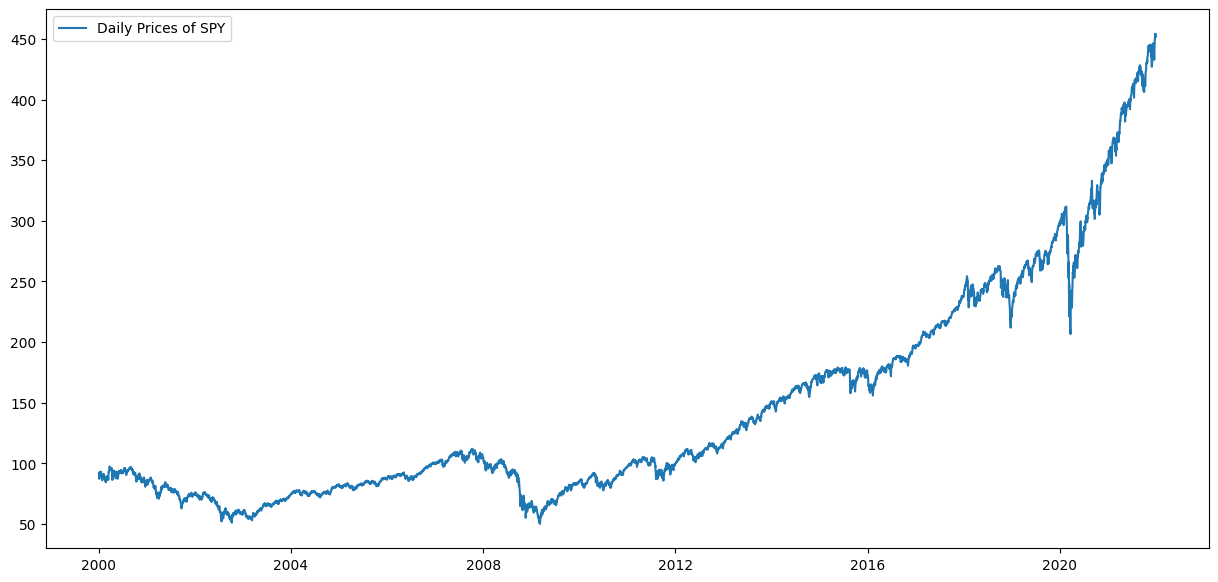

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(df.index, df["Adj Close"], label="Daily Prices of SPY")
plt.legend()
plt.show()

### **2.1 Features**

We aim at forecasting the evolution of SPY 25 days ahead using as input features, $X$, the lags of SPY returns over 10, 25, 60, 120, and 240 days. 

We rescale the information so that all the lags are expressed in daily returns.

In [3]:
df["Ret"] = df["Adj Close"].pct_change()

name = "Ret"
df["Ret10_i"] = (
    df[name].rolling(10).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 10) - 1))
)
df["Ret25_i"] = (
    df[name].rolling(25).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 25) - 1))
)
df["Ret60_i"] = (
    df[name].rolling(60).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 60) - 1))
)
df["Ret120_i"] = (
    df[name].rolling(120).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 120) - 1))
)
df["Ret240_i"] = (
    df[name].rolling(240).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 240) - 1))
)

del df["Open"]
del df["Close"]
del df["High"]
del df["Low"]
del df["Volume"]
del df["Adj Close"]

df = df.dropna()
df.tail(10)

Price,Ret,Ret10_i,Ret25_i,Ret60_i,Ret120_i,Ret240_i
Ticker,,,,,,
Date,,,,,,
2021-12-17,-0.010643,0.176476,-0.019749,0.067481,0.066045,0.092182
2021-12-20,-0.010633,-0.048308,-0.092543,0.046909,0.056429,0.081573
2021-12-21,0.017759,-0.076997,-0.023540,0.081044,0.066503,0.086544
2021-12-22,0.009999,-0.003982,0.000452,0.131609,0.068450,0.093514
2021-12-23,0.006222,0.125872,0.034999,0.139155,0.075143,0.096013
2021-12-27,0.014152,0.172774,0.077671,0.183143,0.083921,0.100753
2021-12-28,-0.000817,0.253749,0.081564,0.162054,0.090063,0.101875
2021-12-29,0.001279,0.335813,0.097969,0.185859,0.082273,0.105461


Thus, the features in this first example are given by:

*   Ret10_i: Last 10-days compounded return
*   Ret25_i: Last 25-days compounded return
*   Ret60_i: Last 60-days compounded return
*   Ret120_i: Last 120-days compounded return
*   Ret240_i: Last 120-days compounded return
*   Ret: Last day return


### **2.2 Target Variable**

As mentioned above, our label (target) $y$ is the vector of returns of SPY over the following 25 days.

In [4]:
df["Ret25"] = df["Ret25_i"].shift(-25)
df = df.dropna()
df.tail(10)

Price,Ret,Ret10_i,Ret25_i,Ret60_i,Ret120_i,Ret240_i,Ret25
Ticker,,,,,,,
Date,,,,,,,
2021-11-11,0.000324,0.118281,0.222904,0.096176,0.089688,0.109046,-0.019749
2021-11-12,0.007547,0.173274,0.260370,0.106138,0.097811,0.107644,-0.092543
2021-11-15,0.000342,0.159487,0.290887,0.093487,0.096443,0.106911,-0.023540
2021-11-16,0.003958,0.158638,0.316624,0.085466,0.099301,0.108672,0.000452
2021-11-17,-0.002429,0.073350,0.292458,0.078764,0.095781,0.104078,0.034999
2021-11-18,0.003397,0.060236,0.239157,0.080923,0.099345,0.106351,0.077671
2021-11-19,-0.001788,0.007680,0.201566,0.087813,0.096541,0.104385,0.081564
2021-11-22,-0.002815,-0.029040,0.178422,0.068264,0.097291,0.106967,0.097969


## **3. Linear Regression**

### **3.1 Our First Model for $g(.)$: Linear Regression**


One of the simplest (if not the simplest) models that we can train with machine learning is the linear regression model. Linear regression imposes $g(.)$ to be a linear function of the inputs to predict the labels. A linear model makes a prediction by simply computing a sum of the input features, each multiplied by a parameter, plus a constant called the bias term (also "intercept"):
$$
\begin{align*}
\widehat{y} = g(X) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + ... + \theta_n x_n
\end{align*}
$$
where 
* $\widehat{y}$ is the predicted value for the label.
* $n$ is the number of features.
* $x_j$ is the $j^{th}$ input feature.
* $\theta_k$ is the $k^{th}$ model parameter, including the bias term $\theta_0$.

Suppose that our training sample contains $m$ instances of labels and input features. Then, the instance $i$ is represented by a label $y^{(i)}$ and a row vector of features 
$$
\begin{align*}
x^{(i)}= \left(x_0^{(i)}, x_1^{(i)}, x_2^{(i)}, \cdots , x_n^{(i)}\right) 
\end{align*}
$$

where the input $x_0$ takes a value of one in all instances, in association with the bias term.

To train the model, we need a criterion to determine how the model fits the training data. The most common performance measure of a regression model is the mean squared error (MSE). Therefore, if we stack the model parameters in a $n\times 1$ column vector $\theta$, we need to find the values for each element of that vector that solves:
$$
\begin{align*}
\underset{\theta}\min \frac{1}{m}\sum_{i=1}^m \left(y^{(i)} - x^{(i)}\theta\right)^2
\end{align*}
$$

The solution to this problem, $\widehat{\theta}$, leads to a closed form expression, called the *Normal Equation*:

$$
\begin{align}
\widehat{\theta}=(X^TX)^{-1}X^Ty
\end{align}
$$

where $X^T$ is the transpose of the feature matrix $X$. The computations involved for such solution, particularly the inverse part, are extremely costly when we have information on a large number of features or too many instances to fit in the memory of the computer.

In machine learning applications, we usually opt for a generic optimization algorithm that is capable of finding optimal solutions to a wide range of problems: **Gradient Descent**. The idea behind this algorithm is to adjust gradually the parameters of the model in order to minimize a cost function, in our case the MSE. The method measures the local gradient of the cost function with respect to a parameter and tweaks the parameters in the direction of the descendent gradient. When the gradient is zero, we have reached a minimum.

An important element of gradient descent is the *learning rate* hyperparameter (more on hyperparameters later). The learning rate determines the size of the adjustment of the parameters after each evaluation of the gradient. A too low learning rate will lead to many iterations in the algorithm; a too high learning rate will lead to divergence in the algorithm.

One option to proceed is to fill $\theta$ with random values, *random initialization*, and then improve the cost function gradually until the algorithm converges to a minimum. Fortunately, the MSE cost function for a linear regression model happens to be a *convex function* that has one global minimum. Hence, Gradient Descent is guaranteed to approach arbitrarily close to the unique minimum, as long as the learning rate is not too high. Moreover, transforming the input features to have a similar scale among them will also help to increase the speed of convergence.

To implement gradient descent, we need to compute the gradient of the cost function with respect to each model parameter $\theta_k$, that is, the *partial derivative*. When we use the MSE as a cost function, the partial derivative is given by:
$$
\begin{align*}
\frac{\partial}{\partial\theta_j}MSE(\theta)=-\frac{2}{m}\sum_{i=1}^m \left(y^{(i)}-x^{(i)}\theta\right)x_j^{(i)}
\end{align*}
$$
Notice that the partial derivative with respect to $\theta_0$ *assumes* that $x_{0}^{(i)}=1$ for all $i$. If we stack all the partial derivatives in a column vector, we obtain the gradient $\nabla_{\theta} MSE(\theta)$, and each step in Gradient Descent leads to an update of the parameter vector given by:
$$
\begin{align*}
\theta^{[next\ step]}=\theta^{[previous\ step]} - \eta \nabla_{\theta} MSE\left(\theta^{[previous\ step]}\right)
\end{align*} 
$$
where $\eta>0$ is the learning rate. We stop the algorithm when the gradient vector becomes tiny, below a tolerance $\epsilon$. To find a good learning rate, we can perform a grid search and eliminate models with a too slow convergence. 

The Gradient Descent algorithm introduced above is called *Batch Gradient Descent*; it uses the whole batch of training data at every step to update the parameters. This method can be slow on very large training sets. To reduce the computational cost of each step we can opt for *Stochastic Gradient Descent*, which computes the gradient at each step based on a single instance picked at random, or for *Mini-Batch Gradient Descent*, which computes the gradients at each step based on random sets of instances (called mini-batches).

With all these concepts in mind, let's train our linear model and determine its ability predict future returns in the training sample. First, we load some libraries needed in this notebook. The Scikit-Learn library will be useful in all the applications of this module.


In [5]:
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

Let's define our input matrix $X$ and label vector $y$. We have 6 input features and 5,271 instances.

In [6]:
Xdf, ydf = df.iloc[:, 0:-1], df.iloc[:, -1]
X = Xdf.astype("float32")
y = ydf.astype("float32")
print(X.shape, y.shape)

(5271, 6) (5271,)


We now train the model to obtain the coefficients that minimize the MSE:

In [7]:
reg = linear_model.LinearRegression().fit(X, y)

In [8]:
reg.coef_

array([-0.52074367,  0.0025165 , -0.06082407, -0.08060042,  0.16785665,
        0.05341211], dtype=float32)

In [9]:
reg.intercept_

0.029713813

Notice that the signs of the coefficients vary, which implies that there is a negative and positive association between the returns of SPY in 25 days and the returns over different past horizons. These are the typical features of a mean-reverting process.

To understand how well the model fits the training data, we can directly use the MSE of the model. However, the MSE is an absolute measure, so we need some benchmark to evaluate the performance of the model. A useful alternative is to compute the coefficient of determination, or $R^2$, defined as:

$$
\begin{align*}
R^2 = 1-\frac{\sum_{i=1}^m \left(y^{(i)}-x^{(i)}\widehat{\theta}\right)^2}{\sum_{i=1}^m \left(y^{(i)}-\overline{y} \right)^2}
\end{align*} 
$$
where $\overline{y}$ is the average of the labels in the training sample. The $R^2$ of the linear regression is a measure of a goodness of fit that indicates the proportion of the variation of the labels that the model can explain. We can also understand the $R^2$ as the prediction gains made by the model against an alternative (benchmark) prediction model that just uses the sample average to predict the labels. In the linear regression setup, if the model includes a bias term, the model that includes one or several input features will always perform at least marginally better than the average prediction in the training sample. In other setups, like out of the training sample or with other models, we can perform arbitrarily worse than the average at making predictions, in which case the $R^2$ can be negative.

Unfortunately, we show below that the linear model demonstrates poor performance in predicting returns in the training sample. In the scatter diagram, we show below, we plot the relationship between the predicted return (horizontal axis) and the actual return (vertical axis). In a model that displays a perfect fit, $R^2$ is one, and all the points would lie on the black line that represents the 45-degree diagonal, that is we would have $\widehat{y}=y$. The model is far from achieving that.

In [10]:
reg.score(X, y)  # R-squared

0.007488658939786341

In [11]:
# Make predictions
y_pred = reg.predict(X)

# The coefficients
print("Coefficients: \n", reg.coef_)
# The mean squared error
print("Mean squared error: %.5f" % mean_squared_error(y, y_pred))
# The coefficient of determination: 1 is perfect prediction
print(
    "Coefficient of determination (R2): %.5f" % r2_score(y, y_pred)
)  # Another way to compute the R-squared

Coefficients: 
 [-0.52074367  0.0025165  -0.06082407 -0.08060042  0.16785665  0.05341211]
Mean squared error: 0.04454
Coefficient of determination (R2): 0.00749


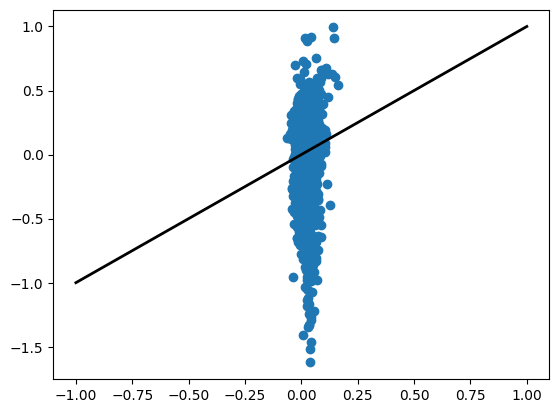

In [12]:
# Plot outputs
plt.scatter(y_pred, y)
plt.plot([-1, 1], [-1, 1], color="black", linewidth=2)
plt.show()

### **3.2 Out-of-Sample vs In-Sample Performance**

In supervised learning, we are interested in training models that are useful to predict the realizations of the labels $y$ of instances whose input features are not used while training the model. To test the predictive ability of the model, we split the data into two samples, a training sample from where we train the model, and a test sample that allows us to evaluate the predictive, or out-of-sample, ability. The out-of-sample error tells us how well the model performs with instances it has never seen before.

In our particular application, we are going to split the sample in half into training and test samples.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=int(len(y) * 0.5), shuffle=False
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(2636, 6) (2635, 6) (2636,) (2635,)


Let's train the model with this new training data.

In [14]:
reg = linear_model.LinearRegression().fit(X_train, y_train)

In [15]:
# Make predictions in the training sample
y_pred = reg.predict(X_train)

# The coefficients
print("Coefficients: \n", reg.coef_)
# The mean squared error
print("Mean squared error: %.5f" % mean_squared_error(y_train, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination (R2): %.5f" % r2_score(y_train, y_pred))

Coefficients: 
 [-0.7030233   0.02207247 -0.07611718  0.03019754  0.2978375  -0.18646364]
Mean squared error: 0.05387
Coefficient of determination (R2): 0.01255


In [16]:
# Make predictions in the test sample
y_pred_test = reg.predict(X_test)

# The coefficients
print("Coefficients: \n", reg.coef_)
# The mean squared error
print(
    "Mean squared error (out-of-sample): %.5f" % mean_squared_error(y_test, y_pred_test)
)
# The coefficient of determination: 1 is perfect prediction
print(
    "Coefficient of determination (R2 out-of-sample): %.5f"
    % r2_score(y_test, y_pred_test)
)

Coefficients: 
 [-0.7030233   0.02207247 -0.07611718  0.03019754  0.2978375  -0.18646364]
Mean squared error (out-of-sample): 0.03701
Coefficient of determination (R2 out-of-sample): -0.08919


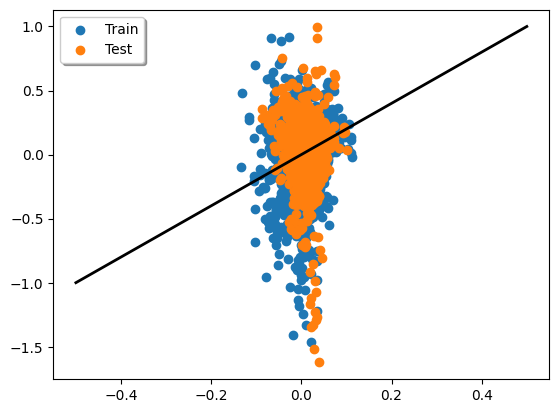

In [17]:
# Plot outputs
plt.scatter(y_pred, y_train, label="Train")
plt.scatter(y_pred_test, y_test, label="Test")
plt.plot([-0.5, 0.5], [-1, 1], color="black", linewidth=2)
legend = plt.legend(loc="upper left", shadow=True)
plt.show()

Notice that using a different training sample leads to different parameters from the trained model that exploit the full data. However, the $R^2$ is still low and the scatterplot above illustrates the poor fit. This model then features an *underfitting* problem. The model is too simple to learn the underlying structure of the data. Linear models are prone to underfit, reality is more complex than the model, and predictions are bound to be inaccurate even on the training sample. If we wish to solve the underfitting of a model, we just need to opt for more complex and flexible models or introduce new input features that may better predict the labels.

Moreover, if we observe the out-of-sample (i.e., test) $R^2$ above, we obtain a negative number. This means that using a prediction that just exploits the sample average of the returns over the test sample would perform better than the trained model. Usually, this low $R^2$ indicates that we are using a oversimplified (underfit) model. You will see how to improve it, using more advanced models, in the next modules. 

Why is the $R^2$ negative? Notice that we train our model to minimize the MSE in the training sample, ignoring the information from the test sample. Indeed, the predictive ability of the model in the training sample has increased relative to the model that uses the whole information for training. The trained model may perform well to match the data in the training sample, but it may be terrible when it faces new information. The MSE of the trained model in the test sample may be much worse than the MSE generated by a prediction based on the average. This boils down to the problem of *overfitting* in machine learning, which we describe next.



Would our predictive model improve by adding further complexity to the model? To further illustrate the overfitting problem, we are going to increase the complexity in the Linear Regression simplest way. This means adding powers of each feature as new features and then train a linear model on this extended set of features. This technique is called Polynomial Regression.

(2636, 24) (2635, 24) (2636,) (2635,)
Coefficients: 
 [-6.4616442e-01  2.1577483e-02 -1.4798753e-01  2.3782025e-01
  4.1236255e-01  3.3159393e-01 -1.5798950e+01  3.1293329e-02
  5.6971836e-01  3.5319829e-01 -1.1888639e+00 -8.1296473e+00
  1.3909866e+02  1.6184920e-02  6.1517674e-02 -1.7734886e+00
  2.6367283e+00 -2.1836758e+01 -1.7441832e+03  1.9114725e-03
 -3.9091209e-01 -2.7051396e+00  6.8091136e-01  3.1738443e+02]
Mean squared error: 0.04716
Coefficient of determination (R2): 0.13558
Coefficients: 
 [-6.4616442e-01  2.1577483e-02 -1.4798753e-01  2.3782025e-01
  4.1236255e-01  3.3159393e-01 -1.5798950e+01  3.1293329e-02
  5.6971836e-01  3.5319829e-01 -1.1888639e+00 -8.1296473e+00
  1.3909866e+02  1.6184920e-02  6.1517674e-02 -1.7734886e+00
  2.6367283e+00 -2.1836758e+01 -1.7441832e+03  1.9114725e-03
 -3.9091209e-01 -2.7051396e+00  6.8091136e-01  3.1738443e+02]
Mean squared error (out-of-sample): 0.04156
Coefficient of determination (R2 out-of-sample): -0.22297


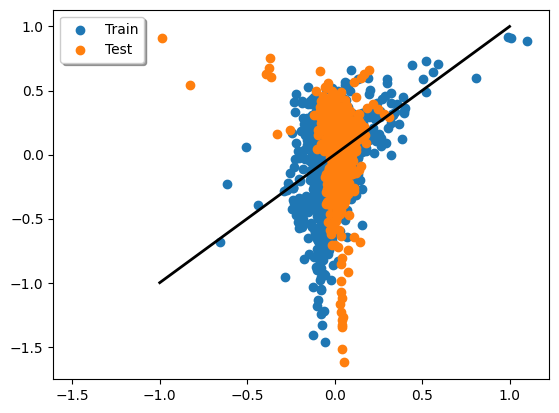

In [18]:
# Polynomial regression
Xpoly = X
for pp in range(2, 5):
    Xpoly = np.concatenate((Xpoly, np.power(X, pp)), axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    Xpoly, y, test_size=int(len(y) * 0.5), shuffle=False
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

reg = linear_model.LinearRegression().fit(X_train, y_train)

# Make predictions in the training sample
y_pred = reg.predict(X_train)

# The coefficients
print("Coefficients: \n", reg.coef_)
# The mean squared error
print("Mean squared error: %.5f" % mean_squared_error(y_train, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination (R2): %.5f" % r2_score(y_train, y_pred))

# Make predictions in the test sample
y_pred_test = reg.predict(X_test)

# The coefficients
print("Coefficients: \n", reg.coef_)
# The mean squared error
print(
    "Mean squared error (out-of-sample): %.5f" % mean_squared_error(y_test, y_pred_test)
)
# The coefficient of determination: 1 is perfect prediction
print(
    "Coefficient of determination (R2 out-of-sample): %.5f"
    % r2_score(y_test, y_pred_test)
)

# Plot outputs
plt.scatter(y_pred, y_train, label="Train")
plt.scatter(y_pred_test, y_test, label="Test")
plt.plot([-1, 1], [-1, 1], color="black", linewidth=2)
legend = plt.legend(loc="upper left", shadow=True)
plt.show()

As you can see in the results above, the prediction performance of the model in the training sample improves and the underfitting decreases, while the out-of-sample performance declines considerably, relative to the basic linear regression model. This is an illustrative example of overfitting. We increase the complexity of the model, but this complex model seems to learn from noise, which damages its out-of-sample performance.

### 3.3 Overfitting

Generalizing from a few observations is usually a trap humans fall into, but machines can also make the same mistake if we are not careful. In Machine Learning, this is called overfitting: the model performs well on training data but does not generalize well when we feed new data into the trained model.

A model's generalization error can be expressed as the sum of three very different errors:

* Bias. This part of the generalization error is due to wrong assumptions, such as assuming that the data is linear when it is actually quadratic. A high-bias model is most likely to underfit the training data.
* Variance. This part is due to the model's excessive sensitivity to small variations in the training data. A model with many degrees of freedom (such as a high-degree polynomial model) is likely to have high variance, and thus to overfit the training data.
* Noise or irreducible error. This part is due to the noisiness of the data itself. The only way to reduce this part of the error is to clean up the data (e.g., fix the data sources or detect and remove outliers).

Increasing a model's complexity will typically increase its variance and reduce its bias. Conversely, reducing a model's complexity increases its bias and reduces its variance. This is why we face a bias-variance trade-off in machine learning.

Sometimes, we do not win with more powerful (i.e., less biased) models when working with limited training data, because of the higher variance of these models. For example, if we change the training data for a model, we are likely to learn a completely different set of parameters (due to its intrinsic noise). The new model is likely to yield a completely different prediction on the same test instance as compared to the predictions using the first training data set. This type of variation in the prediction of the same test instance using different training data sets is a manifestation of model variance, which also adds to the error of the model. Both predictions of the same test instance could not possibly be correct.

If our training set is too small, or too noisy, complex models are probably going to detect patterns from noise. This noise will not generalize to new instances and our model will fail. Some options to reduce the overfitting problem consist of gathering more training data to reduce noise or cleaning the data to fix errors or remove outliers.

Another strategy to reduce overfitting in a complex model is to constrain or *regularize* the parameters. For instance, in the linear regression model above we can restrict certain model parameters to be relatively small, reducing the degrees of freedom to adapt the model. Regularization allows us to find a balance between fitting the data perfectly and keeping the model simple enough to ensure that it will generalize well. In the next lesson, we will describe the most relevant regularization methods.

The amount of regularization to apply during learning can be controlled by a *hyperparameter*, which is a parameter of a learning algorithm, but that does not belong to the prediction model. As such, hyperparameters are fixed during training. Hyperparameter-tuning is an important part of Machine Learning systems.

The choice of hyperparameters allows to discriminate across models to find the one that best performs out-of-sample. Still, a model that performs well with a particular choice of hyperparameters may display a poor performance once we feed the model with new instances. This arises because we chose the hyperparameters to generate the best fit for the test set.

A common solution to this problem is to split our data further into a *validation set*. Then, the choice of models will be done after fitting different models with different hyperparameters in the training set, determine the best model, and hyperparameter based on their performance in the validation set, and then run the model in the test set to have a sense of the generalization error of the model. 

An efficient way to regularize learning algorithms, such as Gradient Descent, is to stop training as long as the validation error reaches a minimum. This is called *early stopping*. This technique stops training when the algorithm starts to overfit the training sample. In that case, we use Mini-Batch or Stochastic Gradient Descent, which exploit random sets of data, and we can use an early stopping rule that stops training if the validation error has been above the minimum for some time. Then, we can roll back the parameters of the model to the point where the minimum error in validation was found.

## **4. Conclusion**

In this first lesson, we have covered the introductory concepts of machine learning. In the next lesson, we will cover the main techniques for parameter regularization, cross-validation, and hyperparameter tuning.

See you there!